In [ ]:
# Identity Overfitting In Deep Learning (Early Stoppping, Regularization)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")
dataset.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1


In [3]:
dataset.isnull().sum()

CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:,-1]

In [5]:
input_data.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57


In [6]:
output_data.head(3)

0    1
1    0
2    1
Name: Exited, dtype: int64

In [7]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)

In [8]:
input_data.shape

(10000, 8)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

In [10]:
x_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6252,-0.564197,-0.660018,-0.695982,0.324119,0.807737,-1.547768,-1.030670,-1.013811
4684,-0.284834,0.388871,-1.387538,-1.225848,0.807737,0.646092,0.970243,0.804921
1731,-0.512463,0.484225,-0.350204,-1.225848,0.807737,0.646092,-1.030670,-0.722147
4742,-1.495407,1.914528,1.032908,0.683816,0.807737,0.646092,0.970243,1.227481
4521,-0.936681,-1.136786,0.687130,0.777477,-0.911583,0.646092,0.970243,0.253524
...,...,...,...,...,...,...,...,...
6412,-0.502117,1.342407,-0.004426,0.349118,-0.911583,-1.547768,0.970243,-0.957298
8285,-0.429689,-1.327494,1.724464,-1.225848,-0.911583,-1.547768,0.970243,0.170498
7853,0.822271,0.770285,0.687130,-1.225848,-0.911583,0.646092,-1.030670,-1.160142
1095,0.429093,-0.946079,-0.350204,-1.225848,-0.911583,0.646092,-1.030670,-0.405759


In [11]:
x_train.shape

(8000, 8)

In [12]:
y_train.shape

(8000,)

In [13]:
import tensorflow

In [81]:
from keras.layers import Dense
from keras.regularizers import L2
from keras.callbacks import EarlyStopping
from keras.models import Sequential

In [82]:
ann = Sequential()

In [83]:
# ann.add(Dense(6, input_dim = 8, activation="relu"))
# ann.add(Dense(4, activation="relu"))
# ann.add(Dense(2, activation="relu"))
# ann.add(Dense(1, activation="sigmoid"))

In [84]:
ann.add(Dense(6, input_dim = 8, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(4, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(2, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(1, activation="sigmoid"))

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

In [86]:
# ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test))

In [93]:
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks=[EarlyStopping()])

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8511 - loss: 0.4161 - val_accuracy: 0.8600 - val_loss: 0.4061
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8515 - loss: 0.4142 - val_accuracy: 0.8610 - val_loss: 0.4038
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8529 - loss: 0.4127 - val_accuracy: 0.8575 - val_loss: 0.4031
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8528 - loss: 0.4110 - val_accuracy: 0.8575 - val_loss: 0.4017
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8525 - loss: 0.4098 - val_accuracy: 0.8570 - val_loss: 0.4017
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8524 - loss: 0.4087 - val_accuracy: 0.8600 - val_loss: 0.3992
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8535 - loss: 0.4074 - val_accuracy: 0.8550 - val_loss: 0.4003


In [88]:
ann.history.history

{'accuracy': [0.5287500023841858,
  0.762624979019165,
  0.793874979019165,
  0.7979999780654907,
  0.796625018119812,
  0.7956249713897705,
  0.7947499752044678,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7946249842643738,
  0.7951250076293945,
  0.7948750257492065,
  0.7958750128746033,
  0.796750009059906,
  0.7988749742507935,
  0.8009999990463257,
  0.800000011920929,
  0.8027499914169312,
  0.8048750162124634,
  0.8062499761581421,
  0.8073750138282776,
  0.8103749752044678,
  0.812125027179718,
  0.8142499923706055,
  0.8149999976158142,
  0.8183749914169312,
  0.8202499747276306,
  0.8207499980926514,
  0.8240000009536743,
  0.8259999752044678,
  0.8262500166893005,
  0.8287500143051147,
  0.8287500143051147,
  0.8288750052452087,
  0.8303750157356262,
  0.8306249976158142,
  0.8351250290870667,
  0.8374999761581421,
  0.

In [95]:
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

In [96]:
len(train_accuracy)

7

In [97]:
len(test_accuracy) == 3

False

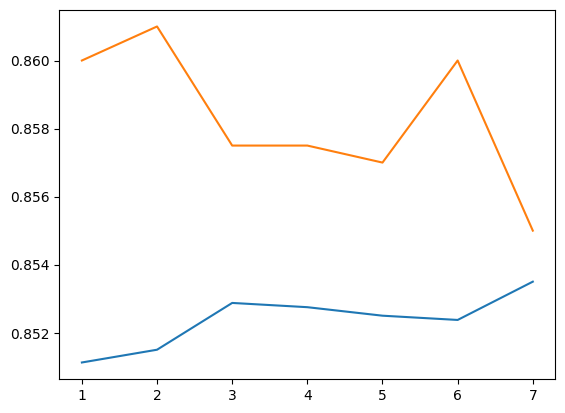

In [98]:
plt.plot([i for i in range(1, 8)], train_accuracy)
plt.plot([i for i in range(1, 8)], test_accuracy)
plt.show()

In [19]:
prd = ann.predict(x_test)
prd_data = []
for i in prd:
    if i[0] > 0.5 :
        prd_data.append(1)
    else:
        prd_data.append(0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [20]:
prd1 = ann.predict(x_train)
prd_data1 = []
for i in prd1:
    if i[0] > 0.5 :
        prd_data1.append(1)
    else:
        prd_data1.append(0)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
from sklearn.metrics import accuracy_score

In [22]:
accuracy_score(y_test, prd_data)*100

85.35000000000001

In [23]:
accuracy_score(y_train, prd_data1)*100

85.6625

In [24]:
input_data2 = np.array([[-0.564197, -0.660018, -0.695982, 0.324119, 
                        0.807737, -1.547768, -1.030670, -1.013811]])

In [25]:
# prd2 = ann.predict([[-0.564197, -0.660018, -0.695982, 0.324119, 0.807737, -1.547768, -1.030670, -1.013811]])
prd2 = ann.predict(input_data)
prd_data2 = []
for i in prd2:
    if i[0] > 0.5 :
        prd_data2.append(1)
    else:
        prd_data2.append(0)
prd_data2

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,


In [26]:
y_test

6252    0
4684    0
1731    0
4742    0
4521    0
       ..
6412    1
8285    0
7853    1
1095    1
6929    1
Name: Exited, Length: 2000, dtype: int64